<a href="https://colab.research.google.com/github/FuscaLuocaG/LUNG-CANCER-ANALYSIS/blob/main/Phase_2_1_lung_cancer_survival_modeling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install scikit-survival
from sksurv.linear_model import CoxPHSurvivalAnalysis

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split

from sksurv.metrics import concordance_index_censored
from sksurv.ensemble import RandomSurvivalForest

In [4]:
df_raw = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/df_NCCCG.csv')

df = df_raw.copy()

In [5]:
df.head()

,inst,time,status,age,sex,ph.ecog,ph.karno,pat.karno,meal.cal,wt.loss
0,3.0,306,1,74,1,1.0,90.0,100.0,1175.0,NaN
1,3.0,455,1,68,1,0.0,90.0,90.0,1225.0,15.0
2,3.0,1010,0,56,1,0.0,90.0,90.0,NaN,15.0
3,5.0,210,1,57,1,1.0,90.0,60.0,1150.0,11.0
4,1.0,883,1,60,1,0.0,100.0,90.0,NaN,0.0


In [6]:
df['ph.ecog'].unique()

array([ 1.,  0.,  2., nan])

# Train - Test Data Sets Split

In [7]:
Y = df[['time', 'status']]

X = df.drop(columns = ['time', 'status'])

In [8]:
x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size = 0.2, random_state = 22, stratify = Y['status'])

print(f"Training set: {x_train.shape[0]} patients")
print(f"Testingg set: {x_test.shape[0]} patients")


Training set: 182 patients
Testingg set: 46 patients


# Missing Values Treatment - KNN Imputation, Standarization and Scalation

In [9]:
num_cols = ['age', 'wt.loss', 'meal.cal', 'pat.karno']
cat_cols = ['sex', 'ph.ecog']

num_pipeline = Pipeline([('imputer', KNNImputer(n_neighbors = 5)), ('scaler', StandardScaler())])

cat_pipeline = Pipeline([('encoder', OneHotEncoder(drop = 'first', sparse_output = False, handle_unknown = 'ignore'))])

preprocessor = ColumnTransformer(transformers = [('num', num_pipeline, num_cols), ('cat', cat_pipeline, cat_cols)])

x_train = preprocessor.fit_transform(x_train)
x_test = preprocessor.transform(x_test)

print(f"Preprocessed x_train shape: {x_train.shape}")
print(f"Preprocessed x_test shape: {x_test.shape}")

Preprocessed x_train shape: (182, 8)
Preprocessed x_test shape: (46, 8)


Converting the Target to a Structured NumPy Array.

In [10]:
y_train_struc = np.array(list(zip(y_train['status'] == 1, y_train['time'])), dtype = [('Status', '?'), ('Time', '<f8')])

y_test_struc = np.array(list(zip(y_test['status'] == 1, y_test['time'])), dtype = [('Status', '?'), ('Time', '<f8')])

print(y_train_struc[:3])
print(y_train_struc.dtype)

[( True, 353.) ( True, 283.) ( True, 351.)]
[('Status', '?'), ('Time', '<f8')]


# Fitting the Cox Proportional Hazards Model

In [11]:
cox_model = CoxPHSurvivalAnalysis()

cox_model.fit(x_train, y_train_struc)

feature_names = num_cols + ['ph.karno', 'sex_male', 'ph.ecog_1', 'ph.ecog_2']

hr_df = pd.DataFrame({'Feature': feature_names, 'Log-Hazard Coef (b)': cox_model.coef_, 'Hazard Ratio (exp(b))': np.exp(cox_model.coef_)}).sort_values(by = 'Hazard Ratio (exp(b))', ascending = False)

hr_df

/usr/local/lib/python3.13/dist-packages/sksurv/linear_model/coxph.py:198: RuntimeWarning: overflow encountered in exp
  risk_set2 += np.exp(xw[k])


,Feature,Log-Hazard Coef (b),Hazard Ratio (exp(b))
7,ph.ecog_2,2.552614,12.840629
6,ph.ecog_1,0.691833,1.997374
5,sex_male,0.169112,1.184253
0,age,0.139037,1.149166
2,meal.cal,-0.043011,0.957900
3,pat.karno,-0.089864,0.914056
1,wt.loss,-0.114642,0.891685
4,ph.karno,-0.535003,0.585667


## Evaluating Cox Proportional Hazards Model

In [12]:
train_risk = cox_model.predict(x_train)
test_risk = cox_model.predict(x_test)

x_index_train = concordance_index_censored(y_train_struc['Status'], y_train_struc['Time'], train_risk)[0]

c_index_test = concordance_index_censored(y_test_struc['Status'], y_test_struc['Time'], test_risk)[0]

print(f"Train C-index: {x_index_train: .4f}")
print(f"Test C-index: {c_index_test: .4f}")

Train C-index:  0.6591
Test C-index:  0.6199


Model Evaluation: Cox Proportional Hazards

- Predictive Performance: The Cox PH model achieved a Test C-Index of 0.6199 (Train C-Index: 0.6591). This indicates that given any two random patients, the model correctly predicts who has a higher risk of earlier mortality ~62% of the time, which aligns with standard clinical survival benchmarks for linear models on small datasets.

- Low Overfitting Risk: The narrow gap ($\Delta \approx 0.04$) between the training and testing C-index scores confirms that our leakage-free preprocessing pipeline prevented the model from memorizing training noise.

- Model Constraints: As a semi-parametric linear estimator, Cox PH assumes proportional hazards and linear relationships between feature values and log-risk. Non-linear patient interactions will be explored next using Random Survival Forests (RSF).

# Fitting Random Survival Forest Model (RSF)

In [13]:
rsf = RandomSurvivalForest(n_estimators = 100, min_samples_split = 10, min_samples_leaf = 15, max_features = 'sqrt', random_state = 22, n_jobs = 1)

rsf.fit(x_train, y_train_struc)

rsf_test_risk = rsf.predict(x_test)
rsf_c_index_test = concordance_index_censored(y_test_struc['Status'], y_test_struc['Time'], rsf_test_risk)[0]

print(f"Cox PH Test C-Index: {c_index_test: .4f}")
print(f"RSF Test C-Index: {rsf_c_index_test: .4f}")

Cox PH Test C-Index:  0.6199
RSF Test C-Index:  0.5922


# Model Comparison & Final Evaluation Table

---------- Model Comparison Summary -----------


,Model,Train C-Index,Test C-Index
0,Cox Proportional Hazards,0.659107,0.619949
1,Random Survival Forest,0.690497,0.592172


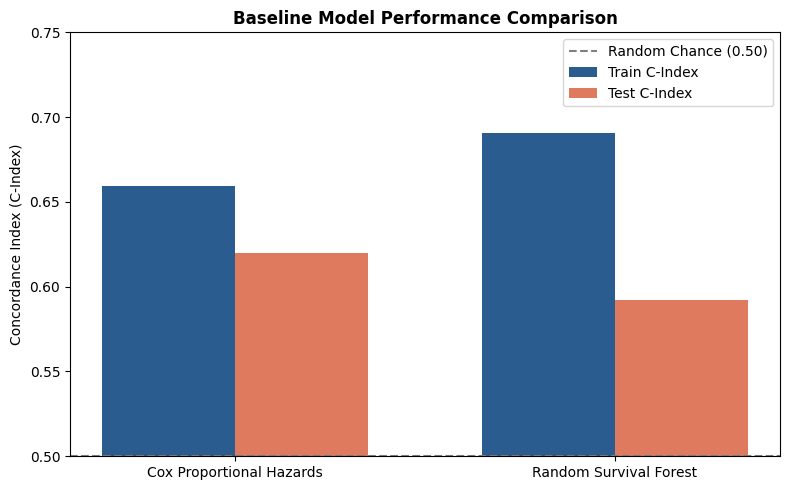

In [14]:
model_comp = pd.DataFrame({'Model' : ['Cox Proportional Hazards', 'Random Survival Forest'], 'Train C-Index': [x_index_train, rsf.score(x_train, y_train_struc)], "Test C-Index": [c_index_test, rsf_c_index_test]})

print("---------- Model Comparison Summary -----------")
display(model_comp)

plt.figure(figsize = (8, 5))
x = np.arange(len(model_comp['Model']))
width = 0.35

plt.bar(x - width/2, model_comp['Train C-Index'], width, label = 'Train C-Index', color = '#2b5c8f')
plt.bar(x + width/2, model_comp['Test C-Index'], width, label='Test C-Index', color='#e07a5f')

plt.ylabel('Concordance Index (C-Index)')
plt.title('Baseline Model Performance Comparison', fontweight = 'bold', fontsize = 12)
plt.xticks(x, model_comp['Model'])
plt.ylim(0.5, 0.75)
plt.axhline(0.5, color = 'gray', linestyle = '--', label = 'Random Chance (0.50)')
plt.legend()
plt.tight_layout()

plt.show()

Models Performances Comparison:

- Small Sample Size : Non-Parametric Models like RSF required large volume of Data to learn deciscion split thrseshold effectively.

- Strong Linear Predictors : Clinical Variables like 'ph.ecog' and 'sex' have strong linear log-hazard relationships. Cox PH estimated these relationships parametric-wise without needing of hundreds of data splits.

- High Feature-to-Sample Ratio in Trees: RSF splits variables randomly at each node. On small datasets with a few dominant features, non-informative feature can weaken tree branches, dgrading performance on test predictions.


Cox PH exhibited a better perfomance due to the good predictions even with a small dataset.

# Predicting Patient Survival Curves (Cox PH)

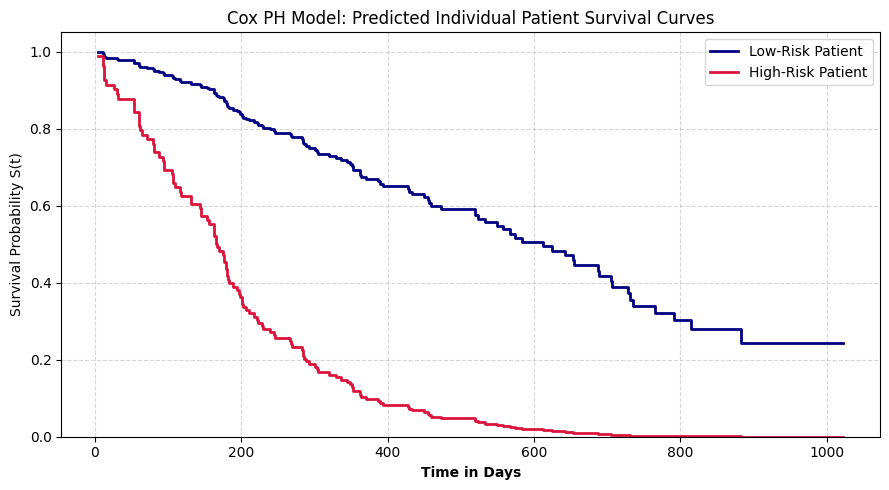

In [19]:
sorted_indices = np.argsort(test_risk)
low_risk_idx = sorted_indices[0]
high_risk_idx = sorted_indices[-1]

surv_funcs = cox_model.predict_survival_function(x_test[[low_risk_idx, high_risk_idx]])

plt.figure(figsize = (9, 5))

for i, surv_func in enumerate(surv_funcs):
  label = "Low-Risk Patient" if i == 0 else "High-Risk Patient"
  color = 'navy' if i == 0 else 'crimson'
  plt.step(surv_func.x, surv_func.y, where = 'post', label = label, color = color, linewidth = 2)

plt.xlabel("Time in Days", fontweight = 'bold')
plt.ylabel("Survival Probability S(t)")
plt.title("Cox PH Model: Predicted Individual Patient Survival Curves")
plt.ylim(0, 1.05)
plt.grid(True, linestyle = '--', alpha = 0.5)
plt.legend()
plt.tight_layout()

plt.show()

 Individual Patient Survival Curves

 - Clinical Interpretation: The Cox PH model successfully generates distinct individual survival probability curves $S(t)$ over time based on patient-specific covariate profiles.

 - Risk Divergence: The high-risk patient trajectory (red) shows a rapid decline in survival probability within the first 200 days, whereas the low-risk patient (navy) maintains over 50% survival probability past 600 days. This demonstrates the model's capacity to stratify individual prognosis effectively across time.

# Feature Importance / Interpretation

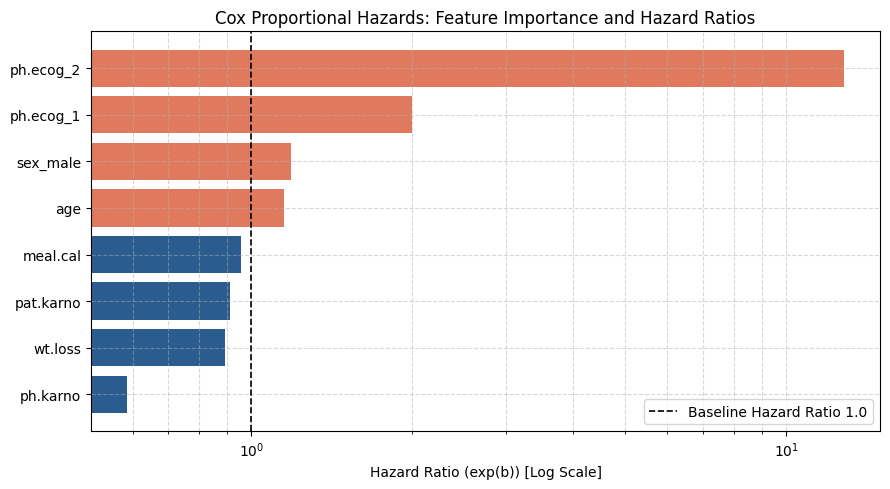

In [22]:
plot_hr = hr_df.sort_values(by = 'Hazard Ratio (exp(b))', ascending = True)

plt.figure(figsize = (9, 5))
colors = ['#2b5c8f' if hr < 1.0 else '#e07a5f' for hr in plot_hr['Hazard Ratio (exp(b))']]

plt.barh(plot_hr['Feature'], plot_hr['Hazard Ratio (exp(b))'], color = colors)
plt.axvline(1.0, color = 'black', linestyle = '--', linewidth = 1.2, label = 'Baseline Hazard Ratio 1.0')

plt.xlabel('Hazard Ratio (exp(b)) [Log Scale]')
plt.xscale('log')
plt.title('Cox Proportional Hazards: Feature Importance and Hazard Ratios')
plt.grid(True, linestyle = '--', alpha = 0.5, which = 'both')
plt.legend()
plt.tight_layout()

plt.show()

Feature Importance & Hazard Ratios

- Primary Hazard Drivers: Physician-assessed functional impairment (ph.ecog_2+ with $\text{HR} \approx 12.8$) is by far the strongest risk factor for earlier mortality, followed by mild ECOG impairment (ph.ecog_1), male sex, and age.

- Protective Factors: High physician Karnofsky performance scores (ph.karno with $\text{HR} \approx 0.59$) act as the strongest protective indicator ($\text{HR} < 1.0$), confirming that higher functional capacity significantly reduces the hazard of death.

## Executive Summary & Clinical Conclusions

### 1. Key Findings
* **Primary Mortality Risk Driver:** Physician-assessed functional status (`ph.ecog_2+`) is the single strongest indicator of early mortality ($\text{HR} \approx 12.84$), showing that severe physical impairment increases mortality hazard nearly 13-fold relative to fully active patients.
* **Protective Factors:** High Karnofsky functional scores (`ph.karno`, $\text{HR} \approx 0.59$) act as significant protective indicators, directly correlating with extended survival duration.
* **Model Selection:** The **Cox Proportional Hazards** model ($\text{Test C-Index} = 0.6199$) outperformed the **Random Survival Forest** ($\text{Test C-Index} = 0.5922$). In small clinical cohorts ($N=228$), parametric linear models generalize better by avoiding overfitting on high-dimensional tree splits.

### 2. Engineering Architecture
* **Data Leakage Prevention:** Built a Scikit-Learn `ColumnTransformer` pipeline executed strictly within an 80/20 stratified train/test split.
* **Target Structuring:** Transformed multi-target clinical observations (`status` and `time`) into structured NumPy boolean/float arrays required for non-parametric and semi-parametric survival estimators.